In [1]:
import sys
sys.path.insert(0, '/home/ethantu/workspace/good-vibrations/src3')

from dataset import VibrationDataset
from model import com as _model_com

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
import json, math, base64, io
from pathlib import Path

from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.signal import find_peaks
from PIL import Image

# 0. Run + Dataset configuration

In [3]:
NORMALIZE_MODE = 'z-global'  # must match the normalize_mode the run's data was processed with

In [4]:
FORWARD_OUTPUTS_DIR = '/home/ethantu/workspace/good-vibrations/runs/1783337515-utopian-jaguarundi/forward_outputs'
MDS_PATH = '/home/ethantu/workspace/good-vibrations/data/mds/c1650bbbf41d93b8'
SAMPLES_OVERHEAD_DIR = '/home/ethantu/workspace/good-vibrations/data/samples'

In [5]:
SPLITS = ['train', 'eval/unseen_pos_speaker', 'eval/unseen_pos', 'eval/unseen_layout']

In [6]:
# Bin sizes in mask pixels for grouping analysis. true_cx ∈ [0, out_w), true_cy ∈ [0, out_h).
epsilon = 0.05
COM_BIN_SIZE_X = 1.6 - epsilon
COM_BIN_SIZE_Y = 2

# 1. Load MDS Dataset

In [7]:
# dataset.jsonl sidecar: first line is data_info (out_h, out_w, n_samples, ...), rest are index_rows.
# sample_id is stored zero-padded ("000000") in the sidecar but as int in the MDS itself
# (see VibrationDataset / tensor_store keys) — cast here so the two line up.
_lines = (Path(MDS_PATH) / 'dataset.jsonl').read_text().strip().splitlines()
data_info = json.loads(_lines[0])
index_rows = [json.loads(line) for line in _lines[1:] if line]
for _row in index_rows:
    _row['sample_id'] = int(_row['sample_id'])
MASK_H, MASK_W = data_info['out_h'], data_info['out_w']
print(f'data_info={data_info}')
print(f'loaded {len(index_rows)} index_rows')

data_info={'out_h': 18, 'out_w': 44, 'n_samples': 688, 'n_laser_rows': 10, 'n_laser_cols': 10, 'patch_size': 256, 'n_freqs': 3328}
loaded 688 index_rows


In [8]:
# tensor_store: single source of truth for mask_true (+ fft/overhead when RAW_DATA_DIR is set), keyed by sample_id
raw_dataset = VibrationDataset(local=MDS_PATH)

tensor_store = {}
for i, row in enumerate(index_rows):
    sid = row['sample_id']
    item = raw_dataset[i]
    tensor_store[sid] = {
        'fft':       item['fft'].numpy(),        # (L, P, PS, 2) float32 — already processed (magnitude-extracted, normalized, tokenized)
        'mask_true': item['mask_true'].numpy(),   # (MASK_H, MASK_W) float32, values in [0, 1]
    }
print(f'loaded {len(tensor_store)} samples  mask shape: {tensor_store[index_rows[0]["sample_id"]]["mask_true"].shape}')

loaded 688 samples  mask shape: (18, 44)


In [9]:
# Optional: wire up overhead photos + full-res segmentation masks from SAMPLES_OVERHEAD_DIR.
# On-disk sample dirs are named f'{sample_id:06d}', matching the MDS's int sample_id
# (int('000008') == 8).
#
# Use 01_resized_overhead.png (clean photo, no mask/speaker baked in) rather than a
# speaker-composited overhead image, which has the segmentation mask and speaker icon
# photoshopped in already — that would visually collide with the mask_true/mask_pred
# overlays plotted on top in plot_predictions.
overhead_img_paths, seg_mask_paths = {}, {}

if SAMPLES_OVERHEAD_DIR is not None:
    samples_dir = Path(SAMPLES_OVERHEAD_DIR)
    for sid in tensor_store:
        sample_dir = samples_dir / f'{sid:06d}' / 'outputs'
        overhead_path = sample_dir / '01_resized_overhead.png'
        seg_mask_path = sample_dir / '02_segment_mask.png'
        if overhead_path.exists(): overhead_img_paths[sid] = overhead_path
        if seg_mask_path.exists(): seg_mask_paths[sid] = seg_mask_path
    print(f'overhead images found:         {len(overhead_img_paths)}/{len(tensor_store)}')
    print(f'full-res segment masks found:  {len(seg_mask_paths)}/{len(tensor_store)}')
else:
    print('SAMPLES_OVERHEAD_DIR not set — skipping overhead/segment-mask lookups')

overhead images found:         688/688
full-res segment masks found:  688/688


In [10]:
# --- Part 1: Dataset rows (always populated) ---
# Columns from MDS index (always): sample_id, n_objects, speaker, box, is_empty_box, object,
#   downsampled_com_x, downsampled_com_y
# Computed from tensor_store (always): true_x_com, true_y_com, bin_cx, bin_cy

def com(mask):
    """Pixel-space (unnormalized) center of mass, via model.py's com()."""
    if mask.sum() == 0: return float('nan'), float('nan')
    t = torch.as_tensor(mask, dtype=torch.float32)
    xs, ys = torch.arange(mask.shape[1]).float(), torch.arange(mask.shape[0]).float()
    cx, cy = _model_com(t, xs, ys, epsilon=1e-6, normalize=False).tolist()
    return cx, cy

def _bin_com(v, size):
    return round(v / size) * size if v is not None and not np.isnan(v) else None

rows = []
for row in index_rows:
    sid = row['sample_id']
    mt = tensor_store[sid]['mask_true']
    tx, ty = com(mt)
    rows.append({
        'sample_id':    sid,
        'n_objects':    row['n_objects'],
        'speakers':     row['speaker'],
        'box':          row['box'],
        'is_empty_box': row['is_empty_box'],
        'object':       row['object'],
        'true_x_com':   tx,
        'true_y_com':   ty,
        'bin_cx':       _bin_com(tx, COM_BIN_SIZE_X),
        'bin_cy':       _bin_com(ty, COM_BIN_SIZE_Y),
    })

df = pd.DataFrame(rows)
df

,sample_id,n_objects,speakers,box,is_empty_box,object,true_x_com,true_y_com,bin_cx,bin_cy
0,0,1,1,metal,False,cube,10.192946,10.846067,10.85,10.0
1,1,1,2,metal,False,cube,10.192946,10.846067,10.85,10.0
2,2,1,3,metal,False,cube,10.192946,10.846067,10.85,10.0
3,3,1,4,metal,False,cube,10.192946,10.846067,10.85,10.0
4,4,1,5,metal,False,cube,10.192946,10.846067,10.85,10.0
...,...,...,...,...,...,...,...,...,...,...
683,683,0,4,metal,True,,NaN,NaN,NaN,NaN
684,684,0,5,metal,True,,NaN,NaN,NaN,NaN
685,685,0,6,metal,True,,NaN,NaN,NaN,NaN
686,686,0,7,metal,True,,NaN,NaN,NaN,NaN


# 2 Load Forward Outputs

In [11]:
def _cat(values):
    """Concatenate per-batch values (tensors or lists) along the sample dim."""
    return torch.cat(values) if isinstance(values[0], torch.Tensor) else sum(values, [])

def load_forward_outputs(forward_outputs_dir):
    """Load every saved .pt output file per split (one per eval batch) and concatenate
    them, so all samples in a split are covered rather than just its last batch.
    Returns run_name and run_data dict."""
    forward_outputs_dir = Path(forward_outputs_dir)
    assert forward_outputs_dir.exists(), f'FORWARD_OUTPUTS_DIR does not exist: {forward_outputs_dir}'

    run_name = forward_outputs_dir.parent.name  # runs/<run_name>/forward_outputs
    run_data = {}
    for split in SPLITS:
        split_dir = forward_outputs_dir / split
        if not split_dir.exists():
            print(f'  skipping {split} (no outputs found)')
            continue
        paths = sorted(split_dir.iterdir())
        print(f'  loading {split} <- {len(paths)} batch file(s): {", ".join(p.name for p in paths)}')
        outputs = [torch.load(p) for p in paths]
        for output in outputs:
            output |= output.pop('info').items()
        keys = outputs[0].keys()
        run_data |= {f'{split}/{k}': _cat([o[k] for o in outputs]) for k in keys}
    return run_name, run_data


RUN_NAME_LOADED, run_data = load_forward_outputs(FORWARD_OUTPUTS_DIR)
print(f'Loaded run: {RUN_NAME_LOADED}')


  loading train <- 8 batch file(s): ep0000-ba000000.pt, ep0000-ba000001.pt, ep0000-ba000002.pt, ep0000-ba000003.pt, ep0000-ba000004.pt, ep0000-ba000005.pt, ep0000-ba000006.pt, ep0000-ba000007.pt
  loading eval/unseen_pos_speaker <- 1 batch file(s): ep0000-ba000000.pt
  loading eval/unseen_pos <- 2 batch file(s): ep0000-ba000000.pt, ep0000-ba000001.pt
  loading eval/unseen_layout <- 1 batch file(s): ep0000-ba000000.pt
Loaded run: 1783337515-utopian-jaguarundi


In [12]:
def build_df_run(run_data):
    """Parse run_data into df_run and store mask_preds in tensor_store."""
    # sanity check: mask_true in run .pt must match the MDS
    print('Sanity checking mask_true (run .pt vs MDS)...')
    n_checked = n_mismatch = 0
    for split in SPLITS:
        if f'{split}/sample_id' not in run_data: continue
        for i in range(len(run_data[f'{split}/sample_id'])):
            sid = run_data[f'{split}/sample_id'][i].item()
            if sid not in tensor_store: continue
            mt_run = np.asarray(run_data[f'{split}/mask_true'][i], dtype=float)
            mt_mds = np.asarray(tensor_store[sid]['mask_true'], dtype=float)
            if not np.allclose(mt_run, mt_mds, atol=1e-4):
                print(f'  MISMATCH  sample_id={sid}  split={split}  max_diff={np.abs(mt_run-mt_mds).max():.5f}')
                n_mismatch += 1
            n_checked += 1
    print(f'  checked {n_checked} samples, {n_mismatch} mismatches')

    run_rows = []
    for split in SPLITS:
        if f'{split}/sample_id' not in run_data: continue
        for i in range(len(run_data[f'{split}/sample_id'])):
            sid = run_data[f'{split}/sample_id'][i].item()

            mt = np.asarray(tensor_store[sid]['mask_true'], dtype=float)
            mp = np.asarray(run_data[f'{split}/mask_pred'][i], dtype=float)

            # store mask_pred in tensor_store (single source of truth)
            tensor_store[sid]['mask_pred'] = mp

            tx, ty = com(mt)
            px_, py_ = com(mp)
            dx, dy = px_ - tx, py_ - ty

            output_id = run_data.get(f'{split}/output_id')
            run_rows.append({
                'split':         split,
                'sample_id':     sid,
                'output_id':     output_id[i] if output_id is not None else None,
                'mse':           float(np.mean((mp - mt) ** 2)),
                'pred_x_com':    px_,
                'pred_y_com':    py_,
                'x_com_diff':    dx,
                'y_com_diff':    dy,
                'com_dist':      float(np.hypot(dx, dy)) if not (np.isnan(dx) or np.isnan(dy)) else float('nan'),
            })

    return pd.DataFrame(run_rows)

if run_data:
    df_run = build_df_run(run_data)
    df = df.merge(df_run, on='sample_id', how='left')
df

Sanity checking mask_true (run .pt vs MDS)...


  checked 688 samples, 0 mismatches


,sample_id,n_objects,speakers,box,is_empty_box,object,true_x_com,true_y_com,bin_cx,bin_cy,split,output_id,mse,pred_x_com,pred_y_com,x_com_diff,y_com_diff,com_dist
0,0,1,1,metal,False,cube,10.192946,10.846067,10.85,10.0,eval/unseen_pos,000000,0.056917,17.524530,7.452221,7.331584,-3.393847,8.079005
1,1,1,2,metal,False,cube,10.192946,10.846067,10.85,10.0,eval/unseen_pos,000000,0.057300,17.504602,7.522789,7.311656,-3.323278,8.031469
2,2,1,3,metal,False,cube,10.192946,10.846067,10.85,10.0,eval/unseen_pos,000000,0.057059,17.706196,7.472915,7.513249,-3.373153,8.235720
3,3,1,4,metal,False,cube,10.192946,10.846067,10.85,10.0,eval/unseen_pos,000000,0.057337,17.511831,7.502426,7.318885,-3.343641,8.046491
4,4,1,5,metal,False,cube,10.192946,10.846067,10.85,10.0,eval/unseen_pos,000000,0.057764,17.484776,7.517996,7.291829,-3.328072,8.015412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,683,0,4,metal,True,,NaN,NaN,NaN,NaN,train,000085,0.003623,24.923004,7.326755,NaN,NaN,NaN
684,684,0,5,metal,True,,NaN,NaN,NaN,NaN,train,000085,0.006912,26.567238,7.345447,NaN,NaN,NaN
685,685,0,6,metal,True,,NaN,NaN,NaN,NaN,train,000085,0.005486,24.453804,7.271827,NaN,NaN,NaN
686,686,0,7,metal,True,,NaN,NaN,NaN,NaN,train,000085,0.010385,27.703787,7.475056,NaN,NaN,NaN


# 3. Summary Statistics

# 4. Dataset Viz

In [13]:
def filter_df(df, split=None, speaker=None, n_objects=None, box=None,
              sample_id=None, x_com=None, y_com=None,
              sort_by='com_dist', ascending=False, max_samples=None):
    df = df.copy()
    if split is not None and 'split' in df.columns:  df = df[df['split'] == split]
    if speaker is not None:      df = df[df['speakers'] == speaker]
    if n_objects is not None:    df = df[df['n_objects'] == n_objects]
    if box is not None:          df = df[df['box'] == box]
    if sample_id is not None:
        ids = [sample_id] if isinstance(sample_id, int) else list(sample_id)
        df = df[df['sample_id'].isin(ids)]
    if x_com is not None:
        df = df[(df['true_x_com'] >= x_com[0]) & (df['true_x_com'] <= x_com[1])]
    if y_com is not None:
        df = df[(df['true_y_com'] >= y_com[0]) & (df['true_y_com'] <= y_com[1])]
    if sort_by is not None and sort_by in df.columns and not df[sort_by].isna().all():
        df = df.sort_values(sort_by, ascending=ascending)
    if max_samples is not None:
        df = df.iloc[:max_samples]
    return df

In [14]:
def plot_predictions(df, split=None, speaker=None, n_objects=None, box=None,
                     sample_id=None, x_com=None, y_com=None,
                     sort_by='com_dist', ascending=False, ncols=6, alpha=0.75, figsize_per_cell=(2.2, 1.9), max_samples=None, background=True):
    """
    Grid of ground-truth / predicted mask pairs, drawn in the overhead photo's native pixel
    space (256x104) so the photo and the full-res segmentation contour line up exactly.
    mask_pred / mask_true (44x18 grid) and the COM markers are rescaled into that same pixel
    space — extent=(0, photo_w, photo_h, 0) — rather than the reverse, since stretching the
    low-res grid up is far less visually distorting than stretching the photo down to 44x18.

    Background = clean overhead photo (01_resized_overhead.png) if available, else mask_true.
    Green outline = full-res ground-truth segmentation mask (02_segment_mask.png) if available.
    Blue heatmap = predicted mask (mask_pred). Green + = true COM. Red + = pred COM.
    """
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from PIL import Image

    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=sort_by,
                    ascending=ascending, max_samples=max_samples)
    if sdf.empty:
        print('No samples match the filter.')
        return

    N = len(sdf)
    nrows = (N + ncols - 1) // ncols

    blues_rgba = plt.get_cmap('Blues')(np.linspace(0.3, 1.0, 256))
    blues_rgba[:, 3] = np.linspace(0, alpha, 256)
    blue_cmap = mcolors.ListedColormap(blues_rgba)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')

    for ax_i, (_, row) in enumerate(sdf.iterrows()):
        ax = axes[ax_i]
        sid = int(row['sample_id'])
        mp = tensor_store[sid].get('mask_pred')

        # extent to draw the 44x18 grid (mask_pred, COM) in — defaults to the mask's own
        # coordinate space, but switches to the photo's pixel space once we know its size.
        grid_extent = (0, MASK_W, MASK_H, 0)

        overhead_path = overhead_img_paths.get(sid) if background else None
        if overhead_path is not None:
            img = Image.open(overhead_path).convert('RGB')
            photo_w, photo_h = img.size
            grid_extent = (0, photo_w, photo_h, 0)
            ax.imshow(img, extent=(0, photo_w, photo_h, 0))
        else:
            mt = tensor_store[sid]['mask_true']
            ax.imshow(mt, cmap='gray_r', vmin=0, vmax=1, extent=grid_extent)

        seg_mask_path = seg_mask_paths.get(sid)
        if seg_mask_path is not None:
            seg_img = Image.open(seg_mask_path).convert('L')
            # Flip vertically: 02_segment_mask.png is stored bottom-up relative to
            # 01_resized_overhead.png, confirmed across multiple samples (incl. sample_id 0/5).
            seg = np.flipud(np.asarray(seg_img) > 127)
            ax.contour(seg, levels=[0.5], colors='lime', linewidths=1, extent=(0, seg_img.width, seg_img.height, 0))

        if mp is not None:
            if background:
                ax.imshow(mp, cmap=blue_cmap, vmin=0, vmax=1, extent=grid_extent)
            else:
                # filled heatmap blends into mask_true's black fill wherever they overlap,
                # making the prediction invisible -- draw it as a contour instead so it never
                # visually merges with the ground-truth region underneath.
                gh_, gw_ = mp.shape
                xs = np.linspace(grid_extent[0], grid_extent[1], gw_)
                ys = np.linspace(grid_extent[3], grid_extent[2], gh_)
                ax.contour(xs, ys, mp, levels=[0.5], colors='blue', linewidths=1)

        gw = grid_extent[1] - grid_extent[0]
        gh = grid_extent[2] - grid_extent[3]
        # keep each cell's box matched to the content's own aspect ratio (mask/photo is very
        # wide/short) instead of stretching to fill figsize_per_cell, which was leaving large
        # bands of empty axes space above/below every panel.
        ax.set_box_aspect(abs(gh) / gw)
        tx, ty = row.get('true_x_com'), row.get('true_y_com')
        if tx is not None and not np.isnan(tx):
            ax.plot(tx / MASK_W * gw, ty / MASK_H * gh, '+', color='lime', markersize=10, mew=2)
        px_, py_ = row.get('pred_x_com'), row.get('pred_y_com')
        if px_ is not None and not (isinstance(px_, float) and np.isnan(px_)):
            ax.plot(px_ / MASK_W * gw, py_ / MASK_H * gh, '+', color='red', markersize=10, mew=2)

        # each piece of metadata gets its own line — cramming them onto one line with
        # separators got unreadable once output_id/mse were added alongside split/spk/dist.
        title_lines = [f'id={sid}']
        if 'split' in row and not pd.isna(row.get('split')): title_lines.append(str(row['split']))
        if 'speakers' in row and not pd.isna(row.get('speakers')): title_lines.append(f"spk={row['speakers']}")
        if 'output_id' in row and not pd.isna(row.get('output_id')): title_lines.append(f"out={row['output_id']}")
        if 'mse' in row and not pd.isna(row.get('mse')): title_lines.append(f"mse={row['mse']:.3f}")
        if 'com_dist' in row and not pd.isna(row.get('com_dist')): title_lines.append(f"d={row['com_dist']:.1f}")
        ax.set_title('\n'.join(title_lines), fontsize=7, linespacing=1.4)
        ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])

    fig.subplots_adjust(hspace=0.9, wspace=0.05)
    plt.show()

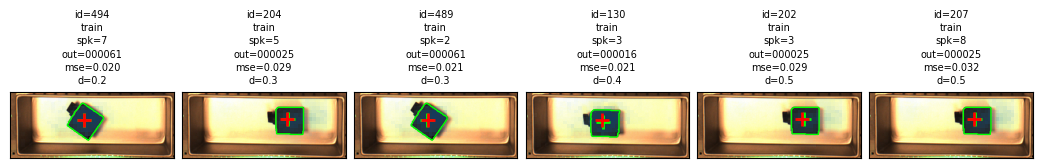

In [15]:
plt.close()
plot_predictions(df, split='train', ascending=True, max_samples=6)

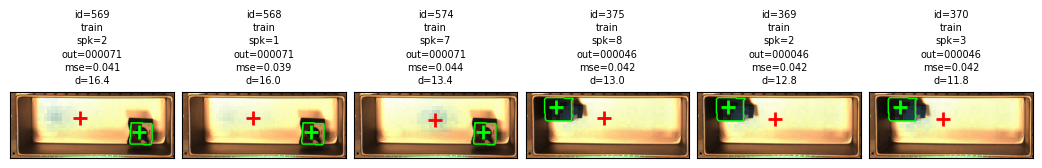

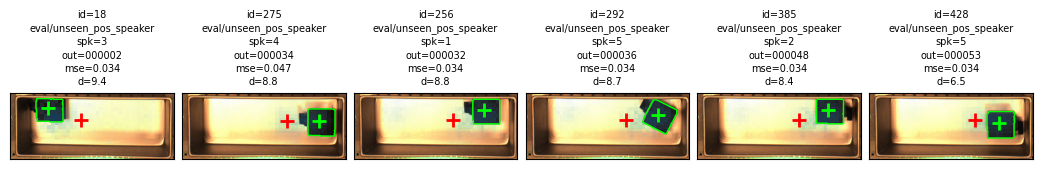

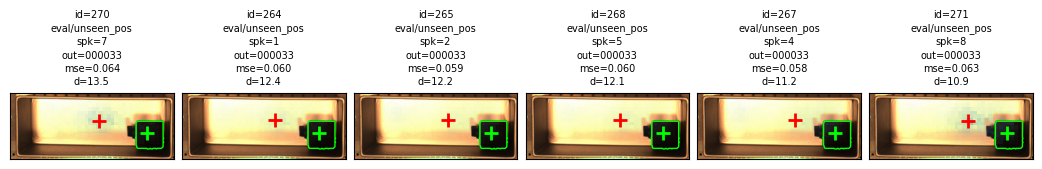

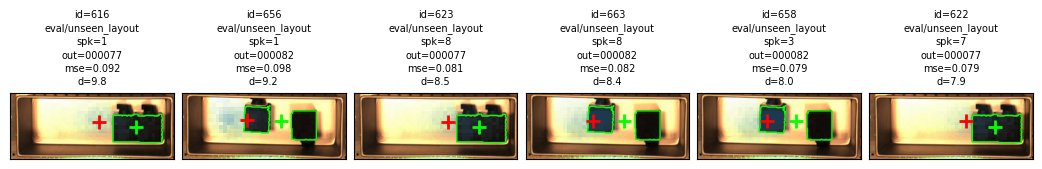

In [16]:
plt.close()
for split in SPLITS: plot_predictions(df, split=split, max_samples=6)

In [17]:
def plot_predictions_side_by_side(df, split=None, speaker=None, n_objects=None, box=None,
                                   sample_id=None, x_com=None, y_com=None,
                                   sort_by='com_dist', ascending=False, ncols=3, max_samples=12):
    """
    Debug view matching the wandb MaskVisualizer callback style: for each sample, mask_true
    and mask_pred are shown as two separate clean grayscale panels (no photo, no overlay,
    no alpha blending) so the predicted mask is always clearly visible regardless of how
    diffuse/low-confidence it is -- unlike the overlay-on-photo approach in plot_predictions,
    where a faint prediction can visually disappear against the background.
    """
    import matplotlib.pyplot as plt

    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=sort_by,
                    ascending=ascending, max_samples=max_samples)
    if sdf.empty:
        print('No samples match the filter.')
        return

    N = len(sdf)
    nrows = (N + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(2.6 * ncols * 2, 2.4 * nrows))
    axes = np.array(axes).reshape(nrows, ncols * 2)
    for ax in axes.flat:
        ax.axis('off')

    for ax_i, (_, row) in enumerate(sdf.iterrows()):
        r, c = divmod(ax_i, ncols)
        ax_pred, ax_true = axes[r, 2 * c], axes[r, 2 * c + 1]
        sid = int(row['sample_id'])
        mp = tensor_store[sid].get('mask_pred')
        mt = tensor_store[sid]['mask_true']

        ax_pred.imshow(mp if mp is not None else np.zeros_like(mt), cmap='gray_r', vmin=0, vmax=1)
        ax_true.imshow(mt, cmap='gray_r', vmin=0, vmax=1)

        title_lines = [f'id={sid}']
        if 'split' in row and not pd.isna(row.get('split')): title_lines.append(str(row['split']))
        if 'mse' in row and not pd.isna(row.get('mse')): title_lines.append(f"mse={row['mse']:.3f}")
        if 'com_dist' in row and not pd.isna(row.get('com_dist')): title_lines.append(f"d={row['com_dist']:.1f}")
        ax_pred.set_title('Predicted\n' + '\n'.join(title_lines), fontsize=7, linespacing=1.3)
        ax_true.set_title('Ground Truth', fontsize=7)
        ax_pred.axis('on'); ax_pred.set_xticks([]); ax_pred.set_yticks([])
        ax_true.axis('on'); ax_true.set_xticks([]); ax_true.set_yticks([])

    fig.subplots_adjust(hspace=0.7, wspace=0.15)
    plt.show()


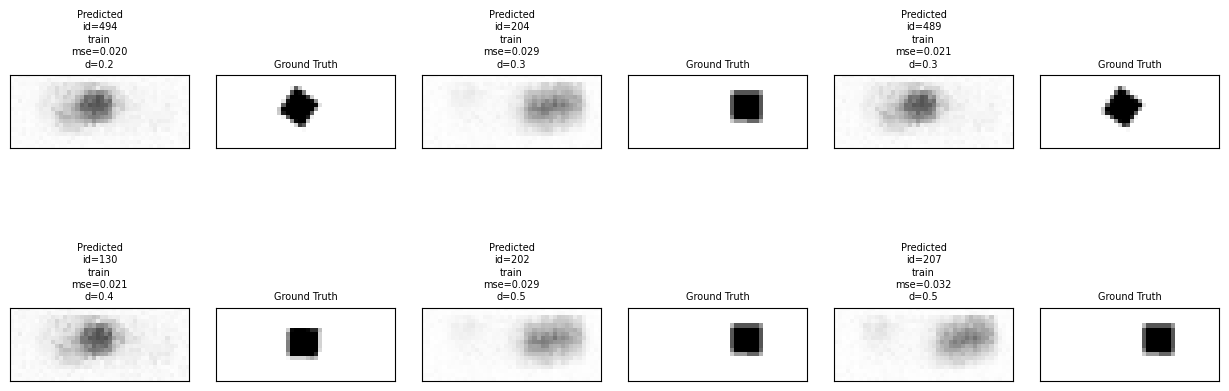

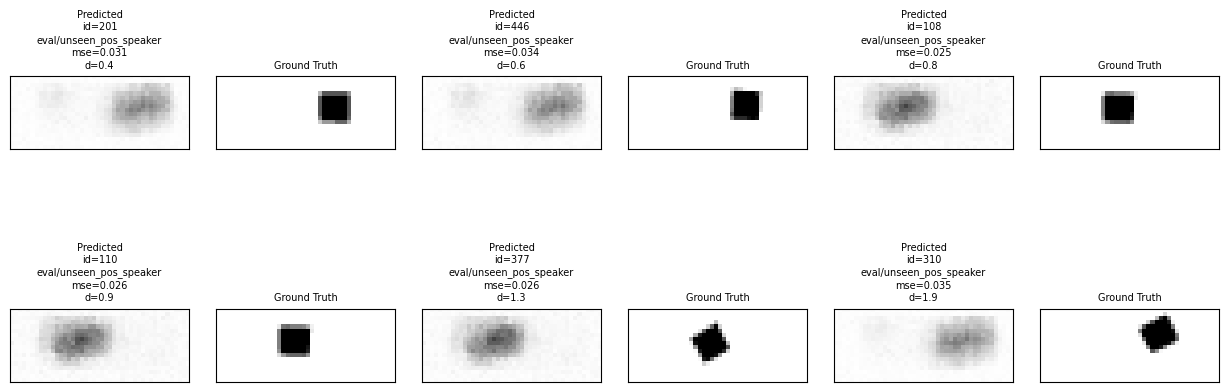

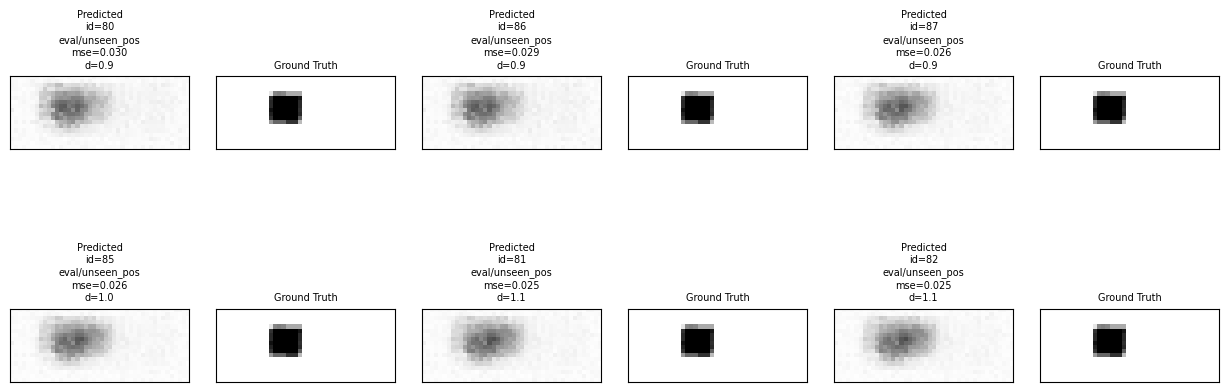

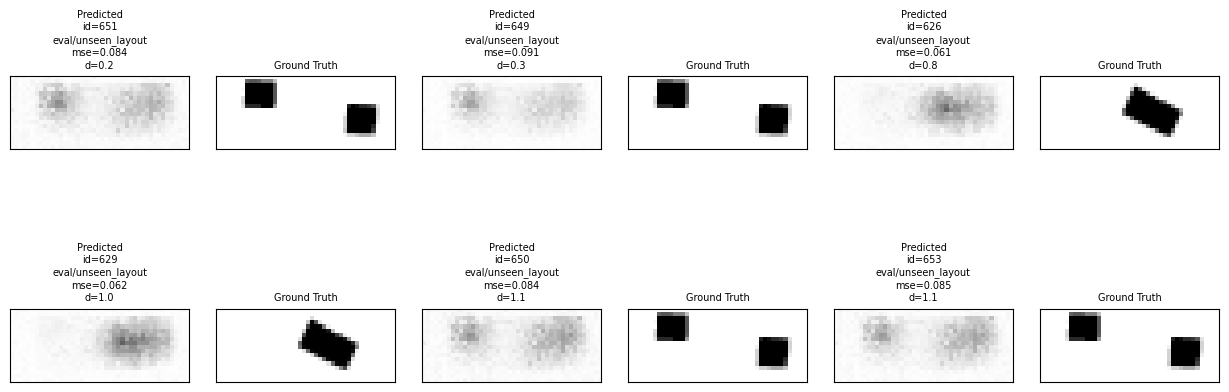

In [28]:
plt.close()
for split in SPLITS: plot_predictions_side_by_side(df, split=split, max_samples=6, ascending=True)

# 5. FFT magnitude spectra

In [19]:
def plot_fft_magnitudes(df, speaker=None, split=None, n_objects=None, box=None,
                        sample_id=None, x_com=None, y_com=None,
                        agg='mean', laser_idx=None,
                        log_y=False, title=None, max_samples=None):
    """
    Plot processed FFT magnitude 'spectra' (already patchified: (L, P, PS, 2)).
    Uses the x-channel (index 0) and flattens patches back to a 1D sequence per laser
    for a rough view — use RAW_DATA_DIR + raw_fft_paths for true unprocessed spectra.

    agg: 'mean' | 'median' | 'max' — how to aggregate across lasers (ignored if laser_idx set)
    laser_idx: int or list of ints — plot specific laser(s) individually instead of aggregating
    """
    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=None, max_samples=max_samples)
    if sdf.empty:
        print('No samples match the filter.')
        return

    fig = go.Figure()
    for _, row in sdf.iterrows():
        sid = int(row['sample_id'])
        fft = tensor_store[sid]['fft']  # (L, P, PS, 2)
        L, P, PS, _ = fft.shape
        mag = fft[..., 0].reshape(L, P * PS)  # (L, F) using x-channel

        if laser_idx is not None:
            idxs = [laser_idx] if isinstance(laser_idx, int) else list(laser_idx)
            spectrum = mag[idxs].mean(0)
        elif agg == 'mean':
            spectrum = mag.mean(0)
        elif agg == 'median':
            spectrum = np.median(mag, axis=0)
        elif agg == 'max':
            spectrum = mag.max(0)

        fig.add_trace(go.Scatter(y=spectrum, mode='lines', name=f'id={sid}', opacity=0.7))

    fig.update_layout(title=title or 'FFT magnitude (processed X, x-channel)',
                      xaxis_title='freq bin', yaxis_title='magnitude',
                      yaxis_type='log' if log_y else 'linear', height=400)
    fig.show()

In [20]:
plot_fft_magnitudes(df, split='train', max_samples=8)

# 6. How does position in the box impact error?

In [21]:
def plot_com_error_heatmap(df, metric='com_dist', agg='mean', speaker=None,
                           split=None, n_objects=None, box=None, sample_id=None,
                           x_com=None, y_com=None,
                           vmax=None, title=None, max_samples=None):
    """
    2D heatmap on the bin_cx / bin_cy grid (binned true COM positions).
    Color = agg(metric) per cell. Count annotation shown in each cell.

    metric: any df column, e.g. 'com_dist', 'mse', 'x_com_diff', 'y_com_diff'
    agg:    'mean', 'median', 'max', 'min', 'std'
    """
    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=None, max_samples=max_samples)
    sdf = sdf.dropna(subset=['bin_cx', 'bin_cy', metric])
    if sdf.empty:
        print('No samples match the filter.')
        return

    xs = sorted(sdf['bin_cx'].unique())
    ys = sorted(sdf['bin_cy'].unique())
    nx, ny = len(xs), len(ys)
    x_idx = {v: i for i, v in enumerate(xs)}
    y_idx = {v: i for i, v in enumerate(ys)}

    agg_fn = {'mean': np.mean, 'median': np.median, 'max': np.max, 'min': np.min, 'std': np.std}[agg]

    z    = np.full((ny, nx), float('nan'))
    text = np.full((ny, nx), '', dtype=object)

    for (bx, by), grp in sdf.groupby(['bin_cx', 'bin_cy']):
        i, j = y_idx[by], x_idx[bx]
        z[i, j] = agg_fn(grp[metric])
        text[i, j] = f'n={len(grp)}'

    default_title = f'{agg}({metric})'
    if split is not None: default_title += f'  [{split}]'

    fig = go.Figure(go.Heatmap(z=z, x=xs, y=ys, text=text, texttemplate='%{text}',
                               colorscale='Oranges', zmax=vmax))
    fig.update_layout(title=title or default_title, xaxis_title='bin_cx', yaxis_title='bin_cy',
                      yaxis_autorange='reversed', height=450)
    fig.show()

In [22]:
if 'com_dist' in df.columns:
    for split in SPLITS:
        if split == 'train': continue
        plot_com_error_heatmap(df, split=split)
else:
    print('No inference run loaded — com_dist unavailable in dataset-only mode.')

# 7. Raw sample table

In [23]:
df2 = filter_df(df)
cols = [c for c in ['sample_id', 'split', 'n_objects', 'speakers', 'box', 'mse', 'pred_x_com', 'pred_y_com',
                    'true_x_com', 'true_y_com', 'x_com_diff', 'y_com_diff', 'com_dist'] if c in df2.columns]
df2[cols]

,sample_id,split,n_objects,speakers,box,mse,pred_x_com,pred_y_com,true_x_com,true_y_com,x_com_diff,y_com_diff,com_dist
569,569,train,1,2,metal,0.041064,18.770399,7.297786,34.723606,10.905794,-15.953207,-3.608008,16.356116
568,568,train,1,1,metal,0.038507,19.183455,7.306135,34.723606,10.905794,-15.540152,-3.599659,15.951610
270,270,eval/unseen_pos,1,7,metal,0.064341,23.791992,7.677336,36.921379,10.920470,-13.129387,-3.243134,13.524005
574,574,train,1,7,metal,0.044073,21.754644,7.615453,34.723606,10.905794,-12.968962,-3.290341,13.379847
375,375,train,1,8,metal,0.042015,20.970276,7.272753,8.303873,4.312877,12.666403,2.959876,13.007637
...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,683,train,0,4,metal,0.003623,24.923004,7.326755,NaN,NaN,NaN,NaN,NaN
684,684,train,0,5,metal,0.006912,26.567238,7.345447,NaN,NaN,NaN,NaN,NaN
685,685,train,0,6,metal,0.005486,24.453804,7.271827,NaN,NaN,NaN,NaN,NaN
686,686,train,0,7,metal,0.010385,27.703787,7.475056,NaN,NaN,NaN,NaN,NaN


# 8. COM distance by speaker, grouped by split

In [24]:
# Fixed categorical order + hues (never cycled/reassigned) so a split keeps its color
# across figures even if some splits are missing from a given df.
SPLIT_COLORS = {
    'train':                   '#2a78d6',  # blue
    'eval/unseen_pos_speaker': '#1baf7a',  # aqua
    'eval/unseen_layout':      '#eda100',  # yellow
    'eval/unseen_pos':         '#4a3aa7',  # violet
}

# 8 fixed categorical hues (validated ordering) for speaker identity when speaker is the
# grouped/colored series instead of the x-axis.
SPEAKER_COLORS = {
    1: '#2a78d6', 2: '#1baf7a', 3: '#eda100', 4: '#008300',
    5: '#4a3aa7', 6: '#e34948', 7: '#e87ba4', 8: '#eb6834',
}

def plot_com_dist_grouped(df, x='speakers', group_by='split', metric='com_dist', title=None):
    """
    Grouped bar chart: `x` on the x-axis, one bar per `group_by` value (fixed color per
    value), bar height = mean(metric), error bar = std(metric). Plotly clusters bars
    sharing an x-value automatically (barmode='group'); missing (x, group_by) combos
    become gaps. Each bar is labeled with mean±std; hovering also shows n (sample count)
    since the label alone can't convey how many samples backed a given bar.

    x, group_by: 'speakers' or 'split' (use one for each — this covers both directions:
    speaker-on-x/split-colored, or split-on-x/speaker-colored).
    """
    color_map = {'split': SPLIT_COLORS, 'speakers': SPEAKER_COLORS}[group_by]
    sdf = df.dropna(subset=[x, group_by, metric])
    if sdf.empty:
        print('No samples with', x, group_by, 'and', metric)
        return

    x_vals = sorted(sdf[x].unique(), key=str) if x != 'split' else \
             [s for s in SPLIT_COLORS if s in sdf[x].unique()]
    group_vals = [g for g in color_map if g in sdf[group_by].unique()] if group_by == 'split' \
                 else sorted(sdf[group_by].unique())

    fig = go.Figure()
    for g in group_vals:
        means, stds, ns = [], [], []
        for xv in x_vals:
            vals = sdf.loc[(sdf[x] == xv) & (sdf[group_by] == g), metric]
            means.append(vals.mean() if len(vals) else np.nan)
            stds.append(vals.std() if len(vals) else np.nan)
            ns.append(len(vals))
        fig.add_trace(go.Bar(
            x=[str(v) for v in x_vals], y=means, name=str(g),
            marker_color=color_map.get(g, '#898781'),
            error_y=dict(type='data', array=stds, color='#52514e', thickness=1, width=3),
            text=[f'{m:.2f}±{s:.2f}' if not np.isnan(m) else '' for m, s in zip(means, stds)],
            textposition='outside',
            customdata=np.stack([stds, ns], axis=-1),
            hovertemplate=(f'{group_by}={g}<br>{x}=%{{x}}<br>mean {metric}=%{{y:.3f}}'
                           '<br>std=%{customdata[0]:.3f}<br>n=%{customdata[1]:.0f}<extra></extra>'),
        ))

    fig.update_layout(
        barmode='group', bargap=0.2, bargroupgap=0.1,
        title=title or f'com_dist ({metric}) by {x}, grouped by {group_by}',
        xaxis_title=x, yaxis_title=f'mean {metric}',
        legend_title=group_by, height=450, width=1600,
    )
    fig.show()

# back-compat alias for the original speaker-on-x / split-colored call sites
def plot_com_dist_by_speaker(df, splits=None, metric='com_dist', title=None):
    plot_com_dist_grouped(df, x='speakers', group_by='split', metric=metric, title=title)

In [25]:
if 'com_dist' in df.columns:
    plot_com_dist_grouped(df, x='speakers', group_by='split')
    plot_com_dist_grouped(df, x='split', group_by='speakers')
else:
    print('No inference run loaded — com_dist unavailable in dataset-only mode.')

In [26]:
def plot_com_dist_stacked_by_speaker(df, group_by='split', metric='com_dist', title=None):
    """
    Stacked bar chart: one bar per speaker, with each `group_by` value's mean(metric)
    stacked cumulatively on top of each other. Total bar height = sum of per-group means,
    making it easy to spot which speaker accumulates the most error across groups.
    Hovering a segment shows its own mean/std/n (not the cumulative value).
    """
    color_map = {'split': SPLIT_COLORS, 'speakers': SPEAKER_COLORS}[group_by]
    sdf = df.dropna(subset=['speakers', group_by, metric])
    if sdf.empty:
        print('No samples with speakers,', group_by, 'and', metric)
        return

    speakers = sorted(sdf['speakers'].unique())
    group_vals = [g for g in color_map if g in sdf[group_by].unique()]

    fig = go.Figure()
    for g in group_vals:
        means, stds, ns = [], [], []
        for spk in speakers:
            vals = sdf.loc[(sdf['speakers'] == spk) & (sdf[group_by] == g), metric]
            means.append(vals.mean() if len(vals) else 0.0)
            stds.append(vals.std() if len(vals) else np.nan)
            ns.append(len(vals))
        fig.add_trace(go.Bar(
            x=[str(s) for s in speakers], y=means, name=str(g),
            marker_color=color_map.get(g, '#898781'),
            customdata=np.stack([stds, ns], axis=-1),
            hovertemplate=(f'{group_by}={g}<br>speaker=%{{x}}<br>mean {metric}=%{{y:.3f}}'
                           '<br>std=%{customdata[0]:.3f}<br>n=%{customdata[1]:.0f}<extra></extra>'),
        ))

    fig.update_layout(
        barmode='stack', bargap=0.2,
        title=title or f'com_dist ({metric}) by speaker, stacked by {group_by}',
        xaxis_title='speaker', yaxis_title=f'cumulative mean {metric}',
        legend_title=group_by, height=450, width=1000,
    )
    fig.show()

if 'com_dist' in df.columns:
    plot_com_dist_stacked_by_speaker(df)
else:
    print('No inference run loaded — com_dist unavailable in dataset-only mode.')

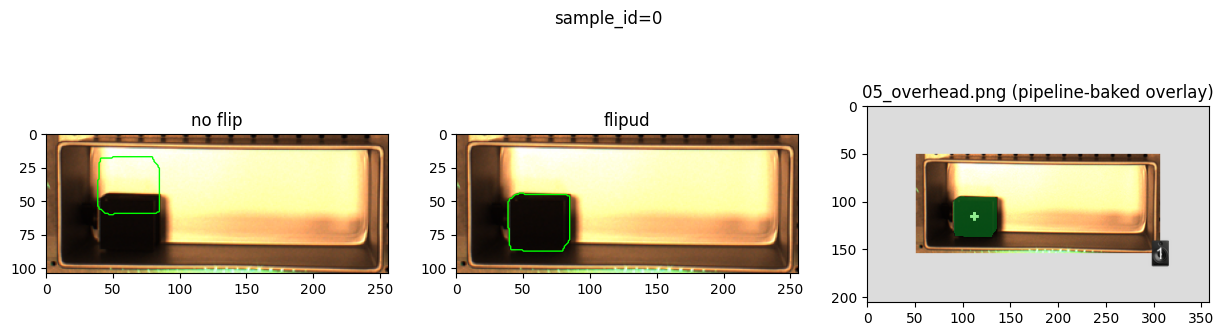

In [27]:
# sanity check: does the segment mask need a vertical flip to line up with the overhead photo?
# compares the newer data/mds/<sample_id>/outputs artifacts (not the possibly-stale
# data/samples_overhead snapshot) against both no-flip and flipud, plus the pipeline's
# own baked-in overlay (05_overhead.png) as ground truth for correct alignment.
def check_flip(sample_id, mds_dir='/home/ethantu/workspace/good-vibrations/data/mds'):
    from PIL import Image
    d = Path(mds_dir) / f'{sample_id:06d}' / 'outputs'
    img = Image.open(d / '01_resized_overhead.png').convert('RGB')
    seg_img = Image.open(d / '02_segment_mask.png').convert('L')
    seg = np.asarray(seg_img) > 127
    photo_w, photo_h = img.size

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img, extent=(0, photo_w, photo_h, 0))
    axes[0].contour(seg, levels=[0.5], colors='lime', linewidths=1, extent=(0, seg_img.width, seg_img.height, 0))
    axes[0].set_title('no flip')

    axes[1].imshow(img, extent=(0, photo_w, photo_h, 0))
    axes[1].contour(np.flipud(seg), levels=[0.5], colors='lime', linewidths=1, extent=(0, seg_img.width, seg_img.height, 0))
    axes[1].set_title('flipud')

    overhead_path = d / '05_overhead.png'
    if overhead_path.exists():
        axes[2].imshow(Image.open(overhead_path))
    axes[2].set_title('05_overhead.png (pipeline-baked overlay)')

    fig.suptitle(f'sample_id={sample_id}')
    plt.show()

check_flip(0)
